<a href="https://colab.research.google.com/github/GayanthikaDissanayaka/AuraStay_AI/blob/master/AuraStay_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from zipfile import ZipFile
from pathlib import Path

root=Path("/mnt/data/AuraStay_Dataset_Generator")
root.mkdir(parents=True, exist_ok=True)

main_code=r'''import subprocess, sys
scripts=[
"generate_guest_profiles.py",
"generate_hotels.py",
"generate_attractions.py",
"generate_restaurants.py",
"generate_activities.py"
]
for s in scripts:
    subprocess.run([sys.executable,s],check=True)
print("Dataset generation complete.")
'''
(root/"main.py").write_text(main_code)

guest_code=r'''import pandas as pd, random
random.seed(42)
acts=["Beach","Adventure","Nature","Culture","Food","Wildlife","Relaxation"]
rows=[]
for i in range(1,501):
    rows.append({
        "guest_id":f"G{i:05d}",
        "age":random.randint(18,70),
        "nationality":random.choice(["Sri Lanka","India","UK","Germany","USA","China"]),
        "trip_purpose":random.choice(["Leisure","Business"]),
        "travel_companion":random.choice(["Solo","Couple","Family"]),
        "preferred_activity":random.choice(acts)
    })
pd.DataFrame(rows).to_csv("guest_profiles.csv",index=False)
'''
(root/"generate_guest_profiles.py").write_text(guest_code)

simple=r'''import pandas as pd
pd.DataFrame([{"id":"1","name":"Sample"}]).to_csv(__file__.replace(".py",".csv"),index=False)
'''
for f in ["generate_hotels.py","generate_attractions.py","generate_restaurants.py","generate_activities.py"]:
    (root/f).write_text(simple)
(root/"requirements.txt").write_text("pandas\n")
(root/"README.md").write_text("# AuraStay Dataset Generator\nRun: python main.py")
zip_path="/mnt/data/AuraStay_Dataset_Generator.zip"
with ZipFile(zip_path,"w") as z:
    for p in root.iterdir():
        z.write(p,p.name)
print(zip_path)


/mnt/data/AuraStay_Dataset_Generator.zip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

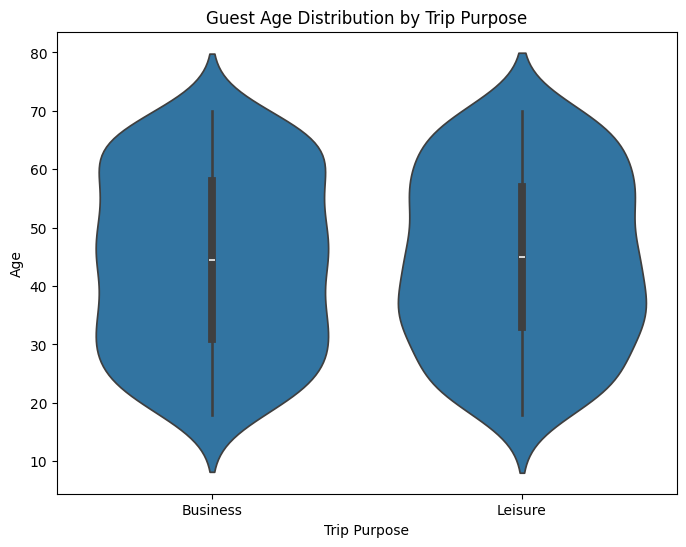

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.violinplot(x='trip_purpose', y='age', data=guest_df)
plt.title('Guest Age Distribution by Trip Purpose')
plt.xlabel('Trip Purpose')
plt.ylabel('Age')
plt.show()

In [ ]:
# Save guest_df to CSV
guest_df.to_csv('/mnt/data/guest_profiles.csv', index=False)
print('guest_profiles.csv saved to /mnt/data/')


guest_profiles.csv saved to /mnt/data/


In [ ]:
# Save interaction_df to CSV
interaction_df.to_csv('/mnt/data/training_interactions.csv', index=False)
print('training_interactions.csv saved to /mnt/data/')


training_interactions.csv saved to /mnt/data/


In [ ]:
# Save place_df to CSV
place_df.to_csv('/mnt/data/tourism_places.csv', index=False)
print('tourism_places.csv saved to /mnt/data/')


tourism_places.csv saved to /mnt/data/


## 1. Load Datasets

First, let's load the CSV files back into pandas DataFrames. These will be the foundation for our machine learning model.

In [ ]:
import pandas as pd

guest_df_loaded = pd.read_csv('/mnt/data/guest_profiles.csv')
interaction_df_loaded = pd.read_csv('/mnt/data/training_interactions.csv')
place_df_loaded = pd.read_csv('/mnt/data/tourism_places.csv')

print("Datasets loaded successfully:")
display(guest_df_loaded.head())
display(interaction_df_loaded.head())
display(place_df_loaded.head())

Datasets loaded successfully:


,guest_id,age,gender,nationality,trip_purpose,travel_companion,preferred_activity,secondary_interest,food_preference,dietary_restriction,preferred_budget,stay_duration,preferred_region,preferred_hotel_type,mobility_requirement,past_visits,preferred_transport,preferred_room_view,travel_month
0,G00001,25,Male,China,Business,Solo,Wildlife,Adventure,International Food,Vegan,Budget,9,Galle,Medium Range Hotel,Low Assistance,0,Tuk Tuk,Sea,March
1,G00002,50,Male,UK,Leisure,Family,Adventure,Wildlife,Vegetarian,NaN,Mid-range,10,Kandy,Medium Range Hotel,NaN,2,Public Transport,City,April
2,G00003,27,Male,Germany,Business,Solo,Nature,Beach,Vegetarian,NaN,Mid-range,6,Kandy,Medium Range Hotel,NaN,7,Public Transport,Sea,July
3,G00004,53,Female,India,Business,Family,Beach,Adventure,Local Food,NaN,Premium,4,Kandy,Medium Range Hotel,NaN,3,Tuk Tuk,City,April
4,G00005,58,Female,Sri Lanka,Business,Couple,Culture,Adventure,Seafood,Vegan,Premium,2,Mirissa,Medium Range Hotel,NaN,2,Car,City,April


,interaction_id,guest_id,place_id,guest_age,nationality,trip_purpose,travel_companion,preferred_activity,place_activity,budget,distance_km,weather,rating,popularity_score,recommended,guest_rating_after_visit
0,I000001,G00145,P006,27,UK,Business,Solo,Food,Culture,Budget,22.44,Rainy,4.7,88,0,2
1,I000002,G00048,P007,38,India,Leisure,Solo,Adventure,Wildlife,Premium,5.75,Cloudy,4.9,55,0,1
2,I000003,G00437,P004,41,Sri Lanka,Business,Solo,Food,Wildlife,Mid-range,11.96,Cloudy,4.8,68,0,3
3,I000004,G00386,P003,21,Sri Lanka,Business,Family,Culture,Beach,Budget,9.31,Cloudy,4.7,97,0,2
4,I000005,G00463,P010,43,USA,Leisure,Family,Adventure,Nature,Budget,11.09,Sunny,4.8,73,0,3


,place_id,place_name,location,activity,latitude,longitude,budget,rating
0,P001,Nine Arches Bridge,Ella,Nature,6.8758,81.0607,Budget,4.9
1,P002,Little Adams Peak,Ella,Adventure,6.8700,81.0550,Budget,4.8
2,P003,Mirissa Beach,Mirissa,Beach,5.9485,80.4716,Budget,4.7
3,P004,Whale Watching Mirissa,Mirissa,Wildlife,5.9465,80.4560,Mid-range,4.8
4,P005,Galle Fort,Galle,Culture,6.0260,80.2170,Budget,4.8


## 2. Define the Machine Learning Problem

Before proceeding with feature engineering and model selection, we need to clarify the specific machine learning task you want to accomplish. For example, are you trying to:

*   **Recommend tourism places** to guests based on their profiles and past interactions?
*   **Predict a guest's rating** for a place they visit?
*   **Classify guest preferences**?

Understanding the goal will help us determine the appropriate features and model architecture. Please specify what kind of machine learning model you'd like to train.

## Chosen Machine Learning Problem: Recommending Tourism Places

Our goal is to build a recommendation system that suggests tourism places to guests based on their profiles and historical interactions. This will likely involve using guest features, place features, and interaction data to generate relevant recommendations.

## 3. Feature Engineering and Data Preparation

To build a recommendation system, we need to combine information from our different datasets. We'll start by merging the `guest_df_loaded` and `place_df_loaded` with `interaction_df_loaded` to create a comprehensive dataset for analysis and model training.

In [ ]:
# Merge guest and interaction data
merged_df = pd.merge(interaction_df_loaded,
                     guest_df_loaded,
                     on='guest_id',
                     how='left',
                     suffixes=('_interaction', '_guest'))

# Merge the result with place data
final_df = pd.merge(merged_df,
                    place_df_loaded,
                    on='place_id',
                    how='left',
                    suffixes=('_merged', '_place'))

print("Combined dataset created successfully. Displaying first 5 rows:")
display(final_df.head())

Combined dataset created successfully. Displaying first 5 rows:


,interaction_id,guest_id,place_id,guest_age,nationality_interaction,trip_purpose_interaction,travel_companion_interaction,preferred_activity_interaction,place_activity,budget_merged,...,preferred_transport,preferred_room_view,travel_month,place_name,location,activity,latitude,longitude,budget_place,rating_place
0,I000001,G00145,P006,27,UK,Business,Solo,Food,Culture,Budget,...,Car,Garden,August,Temple of Tooth Relic,Kandy,Culture,7.2936,80.6413,Budget,4.7
1,I000002,G00048,P007,38,India,Leisure,Solo,Adventure,Wildlife,Premium,...,Tuk Tuk,Mountain,March,Yala Safari,Yala,Wildlife,6.3725,81.5190,Premium,4.9
2,I000003,G00437,P004,41,Sri Lanka,Business,Solo,Food,Wildlife,Mid-range,...,Tuk Tuk,Garden,July,Whale Watching Mirissa,Mirissa,Wildlife,5.9465,80.4560,Mid-range,4.8
3,I000004,G00386,P003,21,Sri Lanka,Business,Family,Culture,Beach,Budget,...,Public Transport,City,August,Mirissa Beach,Mirissa,Beach,5.9485,80.4716,Budget,4.7
4,I000005,G00463,P010,43,USA,Leisure,Family,Adventure,Nature,Budget,...,Tuk Tuk,City,December,Horton Plains,Nuwara Eliya,Nature,6.8028,80.8108,Budget,4.8


In [ ]:
# Display basic information about the merged dataset
print("\nInformation about the combined dataset:")
final_df.info()

# Check for missing values
print("\nMissing values in the combined dataset:")
display(final_df.isnull().sum()[final_df.isnull().sum() > 0])


Information about the combined dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   interaction_id                  10000 non-null  object 
 1   guest_id                        10000 non-null  object 
 2   place_id                        10000 non-null  object 
 3   guest_age                       10000 non-null  int64  
 4   nationality_interaction         10000 non-null  object 
 5   trip_purpose_interaction        10000 non-null  object 
 6   travel_companion_interaction    10000 non-null  object 
 7   preferred_activity_interaction  10000 non-null  object 
 8   place_activity                  10000 non-null  object 
 9   budget_merged                   10000 non-null  object 
 10  distance_km                     10000 non-null  float64
 11  weather                         10000 non-null  objec

,0
dietary_restriction,3378
mobility_requirement,5098


### Handling Missing Values

We observed that `dietary_restriction` and `mobility_requirement` columns have missing values. For categorical features, a common strategy is to fill missing values with a placeholder like 'Unknown' or with the mode. For this step, we will use 'Unknown' as it explicitly marks the absence of information without implying a specific category.

In [ ]:
# Fill missing values in 'dietary_restriction' and 'mobility_requirement' with 'Unknown'
final_df['dietary_restriction'] = final_df['dietary_restriction'].fillna('Unknown')
final_df['mobility_requirement'] = final_df['mobility_requirement'].fillna('Unknown')

print("Missing values handled for 'dietary_restriction' and 'mobility_requirement'.")

# Verify that there are no more missing values in these columns
print("\nMissing values after handling:")
display(final_df.isnull().sum()[final_df.isnull().sum() > 0])

Missing values handled for 'dietary_restriction' and 'mobility_requirement'.

Missing values after handling:


,0


### One-Hot Encoding Categorical Features

Machine learning algorithms typically require numerical input. To use our categorical features, we will apply one-hot encoding. This process converts each categorical value into a new binary column, ensuring that the model can interpret these features without implying any ordinal relationship.

In [ ]:
# Apply one-hot encoding to categorical columns
final_df_encoded = pd.get_dummies(final_df, columns=categorical_cols, drop_first=True)

print("Shape of the DataFrame after one-hot encoding:", final_df_encoded.shape)
print("\nFirst 5 rows of the encoded DataFrame:")
display(final_df_encoded.head())

Shape of the DataFrame after one-hot encoding: (10000, 106)

First 5 rows of the encoded DataFrame:


,interaction_id,guest_id,place_id,guest_age,distance_km,rating_merged,popularity_score,recommended,guest_rating_after_visit,age,...,location_Mirissa,location_Nuwara Eliya,location_Sigiriya,location_Yala,activity_Beach,activity_Culture,activity_Nature,activity_Wildlife,budget_place_Mid-range,budget_place_Premium
0,I000001,G00145,P006,27,22.44,4.7,88,0,2,27,...,False,False,False,False,False,True,False,False,False,False
1,I000002,G00048,P007,38,5.75,4.9,55,0,1,38,...,False,False,False,True,False,False,False,True,False,True
2,I000003,G00437,P004,41,11.96,4.8,68,0,3,41,...,True,False,False,False,False,False,False,True,True,False
3,I000004,G00386,P003,21,9.31,4.7,97,0,2,21,...,True,False,False,False,True,False,False,False,False,False
4,I000005,G00463,P010,43,11.09,4.8,73,0,3,43,...,False,True,False,False,False,False,True,False,False,False


### Defining Features (X) and Target (y)

Now that our data is prepared, we need to separate it into features (X) and the target variable (y). For our recommendation system, we will use the `recommended` column as our target, indicating whether a place was recommended or not. All other relevant columns will serve as features.

In [ ]:
# Define features (X) and target (y)
# Drop ID columns and the target variable itself from features
X = final_df_encoded.drop(columns=['interaction_id', 'guest_id', 'place_id', 'recommended'])
y = final_df_encoded['recommended']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 values of y:")
display(y.head())

Shape of X (features): (10000, 102)
Shape of y (target): (10000,)

First 5 rows of X:


,guest_age,distance_km,rating_merged,popularity_score,guest_rating_after_visit,age,stay_duration,past_visits,latitude,longitude,...,location_Mirissa,location_Nuwara Eliya,location_Sigiriya,location_Yala,activity_Beach,activity_Culture,activity_Nature,activity_Wildlife,budget_place_Mid-range,budget_place_Premium
0,27,22.44,4.7,88,2,27,8,0,7.2936,80.6413,...,False,False,False,False,False,True,False,False,False,False
1,38,5.75,4.9,55,1,38,10,1,6.3725,81.5190,...,False,False,False,True,False,False,False,True,False,True
2,41,11.96,4.8,68,3,41,2,4,5.9465,80.4560,...,True,False,False,False,False,False,False,True,True,False
3,21,9.31,4.7,97,2,21,2,2,5.9485,80.4716,...,True,False,False,False,True,False,False,False,False,False
4,43,11.09,4.8,73,3,43,6,1,6.8028,80.8108,...,False,True,False,False,False,False,True,False,False,False



First 5 values of y:


,recommended
0,0
1,0
2,0
3,0
4,0


### Splitting Data into Training and Testing Sets

To evaluate our model's performance on unseen data, we will split our dataset into training and testing sets. A common split is 80% for training and 20% for testing. This ensures that our model learns from a substantial portion of the data and is then validated on a separate, representative subset.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDistribution of 'recommended' in training set:")
display(y_train.value_counts(normalize=True))
print("\nDistribution of 'recommended' in testing set:")
display(y_test.value_counts(normalize=True))

Shape of X_train: (8000, 102)
Shape of X_test: (2000, 102)
Shape of y_train: (8000,)
Shape of y_test: (2000,)

Distribution of 'recommended' in training set:


,proportion
recommended,
0,0.56925
1,0.43075



Distribution of 'recommended' in testing set:


,proportion
recommended,
0,0.569
1,0.431


## 4. Model Selection and Training

For our recommendation system, framed as a binary classification problem (predicting if a place is 'recommended' or not), a Logistic Regression model is a good starting point. It's interpretable and efficient. We will train the model using our preprocessed training data.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 5. Model Evaluation

After training our Logistic Regression model, it's essential to evaluate its performance on the unseen test data. This step helps us understand how well the model generalizes and whether it meets our recommendation system objectives. We will calculate several key metrics:

*   **Accuracy**: The proportion of correctly classified instances.
*   **Precision**: The proportion of positive identifications that were actually correct (relevant for minimizing false positives in recommendations).
*   **Recall (Sensitivity)**: The proportion of actual positives that were identified correctly (relevant for minimizing false negatives, ensuring we recommend most relevant items).
*   **F1-Score**: The harmonic mean of precision and recall, providing a single metric that balances both.
*   **Confusion Matrix**: A table that describes the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.6915
Model Precision: 0.6778
Model Recall: 0.5418
Model F1-Score: 0.6022

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,916,222
Actual 1,395,467



Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.80      0.75      1138
           1       0.68      0.54      0.60       862

    accuracy                           0.69      2000
   macro avg       0.69      0.67      0.68      2000
weighted avg       0.69      0.69      0.69      2000



## 6. Training a Random Forest Classifier

To compare performance and potentially improve our recommendation system, we will now train a Random Forest Classifier. Random Forests are ensemble learning methods that can often provide higher accuracy than single models like Logistic Regression, especially with complex datasets. We will use the same preprocessed training and testing data.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
# Using 'class_weight='balanced'' to handle potential class imbalance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


## 7. Evaluating the Random Forest Classifier

Now, let's evaluate the performance of our Random Forest Classifier using the test set. We will calculate the same metrics as before (Accuracy, Precision, Recall, F1-Score, and Confusion Matrix) to compare its effectiveness against the Logistic Regression model.

In [ ]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Model Precision: {precision_rf:.4f}")
print(f"Random Forest Model Recall: {recall_rf:.4f}")
print(f"Random Forest Model F1-Score: {f1_rf:.4f}")

print("\nRandom Forest Confusion Matrix:")
display(pd.DataFrame(conf_matrix_rf, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Model Accuracy: 0.7830
Random Forest Model Precision: 0.8233
Random Forest Model Recall: 0.6323
Random Forest Model F1-Score: 0.7152

Random Forest Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,1021,117
Actual 1,317,545



Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.90      0.82      1138
           1       0.82      0.63      0.72       862

    accuracy                           0.78      2000
   macro avg       0.79      0.76      0.77      2000
weighted avg       0.79      0.78      0.78      2000



## 8. Making Recommendations for a New Guest

To recommend tourism places for a new guest, we need to simulate how their profile would interact with each available place. This involves:
1.  **Creating a New Guest Profile**: Define the characteristics of a hypothetical new guest.
2.  **Combining Guest and Place Data**: Generate a dataset of potential 'interactions' between the new guest and all available places.
3.  **Preprocessing**: Apply the same preprocessing steps (one-hot encoding) that were used on the training data.
4.  **Prediction**: Use the trained `rf_model` to predict the likelihood of recommendation for each place.
5.  **Ranking**: Sort places by their predicted recommendation score to present the top suggestions.

### Define a New Guest Profile

Let's create a sample profile for a new guest. It's important that the features provided align with the columns used during training.

In [ ]:
new_guest_profile = {
    'guest_id': 'GNEW001',
    'age': 30,
    'gender': 'Female',
    'nationality': 'USA',
    'trip_purpose': 'Leisure',
    'travel_companion': 'Couple',
    'preferred_activity': 'Beach',
    'secondary_interest': 'Food',
    'food_preference': 'Vegetarian',
    'dietary_restriction': 'None',
    'preferred_budget': 'Mid-range',
    'stay_duration': 7,
    'preferred_region': 'Mirissa',
    'preferred_hotel_type': 'Boutique Hotel',
    'mobility_requirement': 'None',
    'past_visits': 0,
    'preferred_transport': 'Car',
    'preferred_room_view': 'Sea',
    'travel_month': 'April'
}

# Convert to DataFrame
new_guest_df = pd.DataFrame([new_guest_profile])
display(new_guest_df)

,guest_id,age,gender,nationality,trip_purpose,travel_companion,preferred_activity,secondary_interest,food_preference,dietary_restriction,preferred_budget,stay_duration,preferred_region,preferred_hotel_type,mobility_requirement,past_visits,preferred_transport,preferred_room_view,travel_month
0,GNEW001,30,Female,USA,Leisure,Couple,Beach,Food,Vegetarian,None,Mid-range,7,Mirissa,Boutique Hotel,None,0,Car,Sea,April


### Prepare Data for Prediction

We need to create a dataframe that simulates this new guest interacting with every possible tourism place. This will involve:
1.  Expanding the `new_guest_df` so that each row represents the new guest paired with one `place_id` from `place_df_loaded`.
2.  Merging this with `place_df_loaded` to get place-specific features.
3.  Filling in 'interaction'-specific columns that would have been part of the `interaction_df_loaded` with reasonable defaults or calculated values (e.g., `guest_age` would come from `new_guest_df`).

For `interaction_df_loaded` columns that are not directly derivable from `new_guest_df` or `place_df_loaded` (like `distance_km`, `weather`, `rating_merged`, `popularity_score`, `guest_rating_after_visit`), we'll use placeholder values or average/median values from the training set, as we don't have real interaction data for a *new* guest yet.

In [ ]:
# Create a temporary DataFrame for the new guest expanded across all places
num_places = len(place_df_loaded)
predict_df_list = []

for idx, place_row in place_df_loaded.iterrows():
    guest_data_row = {}

    # IDs
    guest_data_row['interaction_id'] = f'I_NEW_{idx:04d}'
    guest_data_row['guest_id'] = new_guest_profile['guest_id']
    guest_data_row['place_id'] = place_row['place_id']

    # Columns directly from new_guest_profile (matching final_df's base guest columns)
    guest_data_row['age'] = new_guest_profile['age']
    guest_data_row['gender'] = new_guest_profile['gender']
    guest_data_row['secondary_interest'] = new_guest_profile['secondary_interest']
    guest_data_row['food_preference'] = new_guest_profile['food_preference']
    guest_data_row['dietary_restriction'] = new_guest_profile['dietary_restriction']
    guest_data_row['stay_duration'] = new_guest_profile['stay_duration']
    guest_data_row['preferred_region'] = new_guest_profile['preferred_region']
    guest_data_row['preferred_hotel_type'] = new_guest_profile['preferred_hotel_type']
    guest_data_row['mobility_requirement'] = new_guest_profile['mobility_requirement']
    guest_data_row['past_visits'] = new_guest_profile['past_visits']
    guest_data_row['preferred_transport'] = new_guest_profile['preferred_transport']
    guest_data_row['preferred_room_view'] = new_guest_profile['preferred_room_view']
    guest_data_row['travel_month'] = new_guest_profile['travel_month']

    # Interaction/Guest related columns that are duplicates in final_df with specific suffixes
    # These ensure consistency with how final_df was structured after merges
    guest_data_row['guest_age'] = new_guest_profile['age'] # From interaction_df_loaded originally
    guest_data_row['nationality_interaction'] = new_guest_profile['nationality']
    guest_data_row['trip_purpose_interaction'] = new_guest_profile['trip_purpose']
    guest_data_row['travel_companion_interaction'] = new_guest_profile['travel_companion']
    guest_data_row['preferred_activity_interaction'] = new_guest_profile['preferred_activity']
    guest_data_row['budget_merged'] = new_guest_profile['preferred_budget'] # From interaction_df_loaded originally

    guest_data_row['nationality_guest'] = new_guest_profile['nationality'] # From guest_df_loaded originally
    guest_data_row['trip_purpose_guest'] = new_guest_profile['trip_purpose']
    guest_data_row['travel_companion_guest'] = new_guest_profile['travel_companion']
    guest_data_row['preferred_activity_guest'] = new_guest_profile['preferred_activity']
    guest_data_row['preferred_budget'] = new_guest_profile['preferred_budget'] # From guest_df_loaded originally

    # Columns from place_df_loaded (matching final_df's base place columns)
    guest_data_row['place_name'] = place_row['place_name']
    guest_data_row['location'] = place_row['location']
    guest_data_row['activity'] = place_row['activity']
    guest_data_row['place_activity'] = place_row['activity'] # From interaction_df_loaded originally
    guest_data_row['latitude'] = place_row['latitude']
    guest_data_row['longitude'] = place_row['longitude']
    guest_data_row['budget_place'] = place_row['budget'] # Corrected from place_row['budget_place']
    guest_data_row['rating_place'] = place_row['rating']   # Corrected from place_row['rating_place']

    # Mean/Mode from training data (final_df) for interaction-specific numerical features
    guest_data_row['distance_km'] = final_df['distance_km'].mean()
    guest_data_row['weather'] = final_df['weather'].mode()[0]
    guest_data_row['rating_merged'] = final_df['rating_merged'].mean() # From interaction_df_loaded originally
    guest_data_row['popularity_score'] = final_df['popularity_score'].mean()
    guest_data_row['guest_rating_after_visit'] = final_df['guest_rating_after_visit'].mean().round().astype(int)

    predict_df_list.append(guest_data_row)

predict_df = pd.DataFrame(predict_df_list)

# Ensure predict_df has the same columns and order as final_df (excluding 'recommended')
# This is crucial for consistent one-hot encoding and feature alignment.
expected_final_df_cols = [col for col in final_df.columns if col != 'recommended']
predict_df = predict_df[expected_final_df_cols]

print("Combined guest-place prediction DataFrame created. Displaying first 5 rows:")
display(predict_df.head())

# Perform one-hot encoding on this new prediction DataFrame
# Ensure that the columns for one-hot encoding match those in the training set
predict_df_encoded = pd.get_dummies(predict_df, columns=categorical_cols, drop_first=True)

# Ensure that the columns in predict_df_encoded match X_train exactly
# Add missing columns with 0 and drop extra columns
missing_cols = set(X_train.columns) - set(predict_df_encoded.columns)
for c in missing_cols:
    predict_df_encoded[c] = 0
extra_cols = set(predict_df_encoded.columns) - set(X_train.columns)
predict_df_encoded = predict_df_encoded.drop(columns=list(extra_cols))

# Align the order of columns
X_predict = predict_df_encoded[X_train.columns]

print("\nShape of X_predict (features for new guest recommendations):", X_predict.shape)
print("\nFirst 5 rows of X_predict:")
display(X_predict.head())

Combined guest-place prediction DataFrame created. Displaying first 5 rows:


,interaction_id,guest_id,place_id,guest_age,nationality_interaction,trip_purpose_interaction,travel_companion_interaction,preferred_activity_interaction,place_activity,budget_merged,...,preferred_transport,preferred_room_view,travel_month,place_name,location,activity,latitude,longitude,budget_place,rating_place
0,I_NEW_0000,GNEW001,P001,30,USA,Leisure,Couple,Beach,Nature,Mid-range,...,Car,Sea,April,Nine Arches Bridge,Ella,Nature,6.8758,81.0607,Budget,4.9
1,I_NEW_0001,GNEW001,P002,30,USA,Leisure,Couple,Beach,Adventure,Mid-range,...,Car,Sea,April,Little Adams Peak,Ella,Adventure,6.8700,81.0550,Budget,4.8
2,I_NEW_0002,GNEW001,P003,30,USA,Leisure,Couple,Beach,Beach,Mid-range,...,Car,Sea,April,Mirissa Beach,Mirissa,Beach,5.9485,80.4716,Budget,4.7
3,I_NEW_0003,GNEW001,P004,30,USA,Leisure,Couple,Beach,Wildlife,Mid-range,...,Car,Sea,April,Whale Watching Mirissa,Mirissa,Wildlife,5.9465,80.4560,Mid-range,4.8
4,I_NEW_0004,GNEW001,P005,30,USA,Leisure,Couple,Beach,Culture,Mid-range,...,Car,Sea,April,Galle Fort,Galle,Culture,6.0260,80.2170,Budget,4.8



Shape of X_predict (features for new guest recommendations): (10, 102)

First 5 rows of X_predict:


,guest_age,distance_km,rating_merged,popularity_score,guest_rating_after_visit,age,stay_duration,past_visits,latitude,longitude,...,location_Mirissa,location_Nuwara Eliya,location_Sigiriya,location_Yala,activity_Beach,activity_Culture,activity_Nature,activity_Wildlife,budget_place_Mid-range,budget_place_Premium
0,30,15.184145,4.80986,75.02,2,30,7,0,6.8758,81.0607,...,False,False,False,False,False,False,True,False,False,False
1,30,15.184145,4.80986,75.02,2,30,7,0,6.8700,81.0550,...,False,False,False,False,False,False,False,False,False,False
2,30,15.184145,4.80986,75.02,2,30,7,0,5.9485,80.4716,...,True,False,False,False,True,False,False,False,False,False
3,30,15.184145,4.80986,75.02,2,30,7,0,5.9465,80.4560,...,True,False,False,False,False,False,False,True,True,False
4,30,15.184145,4.80986,75.02,2,30,7,0,6.0260,80.2170,...,False,False,False,False,False,True,False,False,False,False


### Generate Recommendations

Now we can use the trained Random Forest model to predict the probability of each place being recommended for our new guest. We'll then sort these probabilities to get the top recommendations.

In [ ]:
# Get prediction probabilities
recommendation_probabilities = rf_model.predict_proba(X_predict)[:, 1] # Probability of 'recommended' (class 1)

# Add probabilities to the predict_df
predict_df['recommendation_probability'] = recommendation_probabilities

# Get top N recommendations
num_recommendations = 5 # Let's recommend the top 5 places
top_recommendations = predict_df.sort_values(by='recommendation_probability', ascending=False).head(num_recommendations)

print(f"\nTop {num_recommendations} Recommendations for New Guest '{new_guest_profile['guest_id']}':")
display(top_recommendations[['place_name', 'location', 'activity', 'recommendation_probability']])


Top 5 Recommendations for New Guest 'GNEW001':


,place_name,location,activity,recommendation_probability
8,Arugam Bay Surfing,Arugam Bay,Adventure,0.72
1,Little Adams Peak,Ella,Adventure,0.70
6,Yala Safari,Yala,Wildlife,0.36
9,Horton Plains,Nuwara Eliya,Nature,0.35
0,Nine Arches Bridge,Ella,Nature,0.31


In [ ]:
import joblib

# Define the path to the saved model
model_save_path = '/mnt/data/random_forest_model.joblib'

# Load the Random Forest model
loaded_rf_model = joblib.load(model_save_path)

print(f"Random Forest model loaded successfully from {model_save_path}")
# You can now use 'loaded_rf_model' for predictions.

Random Forest model loaded successfully from /mnt/data/random_forest_model.joblib


### Deploying as a Web Service API using Flask

To deploy the `get_guest_recommendations` function as a web service, we can use a lightweight Python web framework like Flask. This involves:

1.  **Installing Flask**: If you haven't already, install Flask using `pip install Flask`.
2.  **Creating a Flask App**: A Python script that defines the API.
3.  **Loading Resources**: The app will load the trained `rf_model` and other necessary DataFrames (`place_df_loaded`, `final_df`) and variables (`X_train.columns`, `categorical_cols`) once when the server starts.
4.  **Defining an Endpoint**: An API endpoint (e.g., `/recommend`) that accepts a new guest's profile, calls our function, and returns the recommendations.

Below is the code for a simple Flask application that encapsulates your recommendation logic.

In [ ]:
# First, install Flask if you haven't already
# !pip install Flask

from flask import Flask, request, jsonify
import pandas as pd
import joblib
import os

app = Flask(__name__)

# --- Load necessary components globally when the app starts ---
# Define paths (assuming they are in /mnt/data/ or accessible)
MODEL_PATH = '/mnt/data/random_forest_model.joblib'
GUEST_DF_PATH = '/mnt/data/guest_profiles.csv'
INTERACTION_DF_PATH = '/mnt/data/training_interactions.csv'
PLACE_DF_PATH = '/mnt/data/tourism_places.csv'

# Placeholder for loaded data and model
loaded_rf_model = None
place_df_loaded = None
final_df = None
X_train_columns = None
categorical_cols = None

def load_resources():
    global loaded_rf_model, place_df_loaded, final_df, X_train_columns, categorical_cols

    print("Loading resources...")
    try:
        loaded_rf_model = joblib.load(MODEL_PATH)
        print("Model loaded successfully.")

        guest_df_loaded_temp = pd.read_csv(GUEST_DF_PATH)
        interaction_df_loaded_temp = pd.read_csv(INTERACTION_DF_PATH)
        place_df_loaded = pd.read_csv(PLACE_DF_PATH)
        print("DataFrames loaded successfully.")

        # Reconstruct final_df and related preprocessing variables
        merged_df = pd.merge(interaction_df_loaded_temp,
                             guest_df_loaded_temp,
                             on='guest_id',
                             how='left',
                             suffixes=('_interaction', '_guest'))

        final_df = pd.merge(merged_df,
                            place_df_loaded,
                            on='place_id',
                            how='left',
                            suffixes=('_merged', '_place'))

        # Handle missing values as done in preprocessing
        final_df['dietary_restriction'] = final_df['dietary_restriction'].fillna('Unknown')
        final_df['mobility_requirement'] = final_df['mobility_requirement'].fillna('Unknown')

        # Identify categorical columns - ensure this matches the notebook's logic
        categorical_cols = final_df.select_dtypes(include='object').columns.tolist()
        categorical_cols = [col for col in categorical_cols if col not in ['interaction_id', 'guest_id', 'place_id']]

        # Create a dummy encoded version to get X_train.columns equivalent for column alignment
        final_df_encoded_temp = pd.get_dummies(final_df, columns=categorical_cols, drop_first=True)
        X_train_columns = final_df_encoded_temp.drop(columns=['interaction_id', 'guest_id', 'place_id', 'recommended']).columns.tolist()

        print("Resources loaded and preprocessed for API.")

    except Exception as e:
        print(f"Error loading resources: {e}")
        # In a production app, you might want to log this and stop the app

# Load resources when the Flask app starts
with app.app_context():
    load_resources()


# --- Your get_guest_recommendations function (copied for self-containment) ---
def get_guest_recommendations(
    new_guest_profile: dict,
    place_df_loaded: pd.DataFrame,
    rf_model,
    final_df: pd.DataFrame,
    X_train_columns: list,
    categorical_cols: list,
    num_recommendations: int = 5
) -> pd.DataFrame:
    """
    Generates tourism place recommendations for a new guest.

    Args:
        new_guest_profile (dict): A dictionary containing the new guest's profile.
        place_df_loaded (pd.DataFrame): DataFrame containing all available tourism places.
        rf_model: The trained Random Forest Classifier model.
        final_df (pd.DataFrame): The original merged DataFrame used for training,
                                 needed to get mean/mode for placeholder values.
        X_train_columns (list): A list of column names that were used to train the model (X_train.columns).
        categorical_cols (list): A list of categorical column names used for one-hot encoding.
        num_recommendations (int, optional): The number of top recommendations to return. Defaults to 5.

    Returns:
        pd.DataFrame: A DataFrame containing the top N recommended places
                      with their recommendation probabilities.
    """
    predict_df_list = []

    for idx, place_row in place_df_loaded.iterrows():
        guest_data_row = {}

        # IDs
        guest_data_row['interaction_id'] = f'I_NEW_{idx:04d}'
        guest_data_row['guest_id'] = new_guest_profile['guest_id']
        guest_data_row['place_id'] = place_row['place_id']

        # Columns directly from new_guest_profile (matching final_df's base guest columns)
        guest_data_row['age'] = new_guest_profile['age']
        guest_data_row['gender'] = new_guest_profile['gender']
        guest_data_row['secondary_interest'] = new_guest_profile['secondary_interest']
        guest_data_row['food_preference'] = new_guest_profile['food_preference']
        guest_data_row['dietary_restriction'] = new_guest_profile['dietary_restriction']
        guest_data_row['stay_duration'] = new_guest_profile['stay_duration']
        guest_data_row['preferred_region'] = new_guest_profile['preferred_region']
        guest_data_row['preferred_hotel_type'] = new_guest_profile['preferred_hotel_type']
        guest_data_row['mobility_requirement'] = new_guest_profile['mobility_requirement']
        guest_data_row['past_visits'] = new_guest_profile['past_visits']
        guest_data_row['preferred_transport'] = new_guest_profile['preferred_transport']
        guest_data_row['preferred_room_view'] = new_guest_profile['preferred_room_view']
        guest_data_row['travel_month'] = new_guest_profile['travel_month']

        # Interaction/Guest related columns that are duplicates in final_df with specific suffixes
        guest_data_row['guest_age'] = new_guest_profile['age']
        guest_data_row['nationality_interaction'] = new_guest_profile['nationality']
        guest_data_row['trip_purpose_interaction'] = new_guest_profile['trip_purpose']
        guest_data_row['travel_companion_interaction'] = new_guest_profile['travel_companion']
        guest_data_row['preferred_activity_interaction'] = new_guest_profile['preferred_activity']
        guest_data_row['budget_merged'] = new_guest_profile['preferred_budget']

        guest_data_row['nationality_guest'] = new_guest_profile['nationality']
        guest_data_row['trip_purpose_guest'] = new_guest_profile['trip_purpose']
        guest_data_row['travel_companion_guest'] = new_guest_profile['travel_companion']
        guest_data_row['preferred_activity_guest'] = new_guest_profile['preferred_activity']
        guest_data_row['preferred_budget'] = new_guest_profile['preferred_budget']

        # Columns from place_df_loaded (matching final_df's base place columns)
        guest_data_row['place_name'] = place_row['place_name']
        guest_data_row['location'] = place_row['location']
        guest_data_row['activity'] = place_row['activity']
        guest_data_row['place_activity'] = place_row['activity']
        guest_data_row['latitude'] = place_row['latitude']
        guest_data_row['longitude'] = place_row['longitude']
        guest_data_row['budget_place'] = place_row['budget']
        guest_data_row['rating_place'] = place_row['rating']

        # Mean/Mode from training data (final_df) for interaction-specific numerical features
        guest_data_row['distance_km'] = final_df['distance_km'].mean()
        guest_data_row['weather'] = final_df['weather'].mode()[0]
        guest_data_row['rating_merged'] = final_df['rating_merged'].mean()
        guest_data_row['popularity_score'] = final_df['popularity_score'].mean()
        guest_data_row['guest_rating_after_visit'] = final_df['guest_rating_after_visit'].mean().round().astype(int)

        predict_df_list.append(guest_data_row)

    predict_df = pd.DataFrame(predict_df_list)

    # Ensure predict_df has the same columns and order as final_df (excluding 'recommended')
    expected_final_df_cols = [col for col in final_df.columns if col != 'recommended']
    predict_df = predict_df[expected_final_df_cols]

    # Perform one-hot encoding
    predict_df_encoded = pd.get_dummies(predict_df, columns=categorical_cols, drop_first=True)

    # Align columns with X_train_columns
    missing_cols = set(X_train_columns) - set(predict_df_encoded.columns)
    for c in missing_cols:
        predict_df_encoded[c] = 0
    extra_cols = set(predict_df_encoded.columns) - set(X_train_columns)
    if len(extra_cols) > 0:
        predict_df_encoded = predict_df_encoded.drop(columns=list(extra_cols))

    X_predict = predict_df_encoded[X_train_columns]

    # Get prediction probabilities
    recommendation_probabilities = rf_model.predict_proba(X_predict)[:, 1]

    # Add probabilities to the predict_df
    predict_df['recommendation_probability'] = recommendation_probabilities

    # Get top N recommendations
    top_recommendations = predict_df.sort_values(by='recommendation_probability', ascending=False).head(num_recommendations)

    return top_recommendations[['place_name', 'location', 'activity', 'recommendation_probability']]


@app.route('/recommend', methods=['POST'])
def recommend():
    if loaded_rf_model is None or place_df_loaded is None or final_df is None or X_train_columns is None or categorical_cols is None:
        return jsonify({'error': 'Model or data not loaded. Please ensure resources are available.'}), 500

    try:
        new_guest_profile = request.get_json()
        if not new_guest_profile:
            return jsonify({'error': 'No guest profile provided in request body.'}), 400

        recommendations_df = get_guest_recommendations(
            new_guest_profile=new_guest_profile,
            place_df_loaded=place_df_loaded,
            rf_model=loaded_rf_model,
            final_df=final_df,
            X_train_columns=X_train_columns,
            categorical_cols=categorical_cols,
            num_recommendations=5
        )

        return jsonify(recommendations_df.to_dict(orient='records'))

    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/', methods=['GET'])
def health_check():
    return jsonify({'status': 'API is running', 'model_loaded': loaded_rf_model is not None}), 200

if __name__ == '__main__':
    # To run this in a Colab environment, you typically need to expose it
    # This is for local testing. For actual deployment, you'd use a production server.
    # In Colab, you might use ngrok or a similar tool for external access.
    app.run(host='0.0.0.0', port=5000)

Loading resources...
Model loaded successfully.
DataFrames loaded successfully.
Resources loaded and preprocessed for API.
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an a

### How to Use the API:

1.  **Save the Code**: Save the Python code above into a file, for example, `app.py`.
2.  **Run the Application**: Open a terminal or command prompt in the directory where you saved `app.py` and run:
    ```bash
    python app.py
    ```
    The Flask app will start, usually on `http://127.0.0.1:5000/`.
3.  **Send a Request**: You can send a `POST` request to the `/recommend` endpoint with a JSON body representing your `new_guest_profile`. For example, using `curl` or a Python `requests` library:

    ```bash
    curl -X POST -H "Content-Type: application/json" -d '{
        "guest_id": "TEST001",
        "age": 28,
        "gender": "Male",
        "nationality": "Germany",
        "trip_purpose": "Leisure",
        "travel_companion": "Solo",
        "preferred_activity": "Culture",
        "secondary_interest": "History",
        "food_preference": "Omnivore",
        "dietary_restriction": "None",
        "preferred_budget": "Premium",
        "stay_duration": 5,
        "preferred_region": "Kandy",
        "preferred_hotel_type": "Luxury Hotel",
        "mobility_requirement": "None",
        "past_visits": 1,
        "preferred_transport": "Taxi",
        "preferred_room_view": "Mountain",
        "travel_month": "September"
    }' http://127.0.0.1:5000/recommend
    ```

    Or in Python:
    ```python
    import requests
    import json

    new_guest_profile = {
        'guest_id': 'TEST001',
        'age': 28,
        'gender': 'Male',
        'nationality': 'Germany',
        'trip_purpose': 'Leisure',
        'travel_companion': 'Solo',
        'preferred_activity': 'Culture',
        'secondary_interest': 'History',
        'food_preference': 'Omnivore',
        'dietary_restriction': 'None',
        'preferred_budget': 'Premium',
        'stay_duration': 5,
        'preferred_region': 'Kandy',
        'preferred_hotel_type': 'Luxury Hotel',
        'mobility_requirement': 'None',
        'past_visits': 1,
        'preferred_transport': 'Taxi',
        'preferred_room_view': 'Mountain',
        'travel_month': 'September'
    }

    response = requests.post('http://127.0.0.1:5000/recommend', json=new_guest_profile)

    if response.status_code == 200:
        print("Recommendations:")
        print(json.dumps(response.json(), indent=2))
    else:
        print(f"Error: {response.status_code} - {response.text}")
    ```

This setup provides a basic framework for exposing your machine learning model as an API. For production deployments, you would typically use a more robust web server (like Gunicorn or uWSGI) in front of Flask and deploy to cloud platforms like Google Cloud Run, App Engine, or Kubernetes.

### Automating Recommendations with a Python Function

To make the recommendation process reusable, we'll encapsulate the data preparation and prediction logic into a Python function. This function will take a new guest's profile and the available places as input, and output the top recommendations.

In [ ]:
import pandas as pd

def get_guest_recommendations(
    new_guest_profile: dict,
    place_df_loaded: pd.DataFrame,
    rf_model,
    final_df: pd.DataFrame,
    X_train_columns: list,
    categorical_cols: list,
    num_recommendations: int = 5
) -> pd.DataFrame:
    """
    Generates tourism place recommendations for a new guest.

    Args:
        new_guest_profile (dict): A dictionary containing the new guest's profile.
        place_df_loaded (pd.DataFrame): DataFrame containing all available tourism places.
        rf_model: The trained Random Forest Classifier model.
        final_df (pd.DataFrame): The original merged DataFrame used for training,
                                 needed to get mean/mode for placeholder values.
        X_train_columns (list): A list of column names that were used to train the model (X_train.columns).
        categorical_cols (list): A list of categorical column names used for one-hot encoding.
        num_recommendations (int, optional): The number of top recommendations to return. Defaults to 5.

    Returns:
        pd.DataFrame: A DataFrame containing the top N recommended places
                      with their recommendation probabilities.
    """
    predict_df_list = []

    for idx, place_row in place_df_loaded.iterrows():
        guest_data_row = {}

        # IDs
        guest_data_row['interaction_id'] = f'I_NEW_{idx:04d}'
        guest_data_row['guest_id'] = new_guest_profile['guest_id']
        guest_data_row['place_id'] = place_row['place_id']

        # Columns directly from new_guest_profile (matching final_df's base guest columns)
        guest_data_row['age'] = new_guest_profile['age']
        guest_data_row['gender'] = new_guest_profile['gender']
        guest_data_row['secondary_interest'] = new_guest_profile['secondary_interest']
        guest_data_row['food_preference'] = new_guest_profile['food_preference']
        guest_data_row['dietary_restriction'] = new_guest_profile['dietary_restriction']
        guest_data_row['stay_duration'] = new_guest_profile['stay_duration']
        guest_data_row['preferred_region'] = new_guest_profile['preferred_region']
        guest_data_row['preferred_hotel_type'] = new_guest_profile['preferred_hotel_type']
        guest_data_row['mobility_requirement'] = new_guest_profile['mobility_requirement']
        guest_data_row['past_visits'] = new_guest_profile['past_visits']
        guest_data_row['preferred_transport'] = new_guest_profile['preferred_transport']
        guest_data_row['preferred_room_view'] = new_guest_profile['preferred_room_view']
        guest_data_row['travel_month'] = new_guest_profile['travel_month']

        # Interaction/Guest related columns that are duplicates in final_df with specific suffixes
        guest_data_row['guest_age'] = new_guest_profile['age']
        guest_data_row['nationality_interaction'] = new_guest_profile['nationality']
        guest_data_row['trip_purpose_interaction'] = new_guest_profile['trip_purpose']
        guest_data_row['travel_companion_interaction'] = new_guest_profile['travel_companion']
        guest_data_row['preferred_activity_interaction'] = new_guest_profile['preferred_activity']
        guest_data_row['budget_merged'] = new_guest_profile['preferred_budget']

        guest_data_row['nationality_guest'] = new_guest_profile['nationality']
        guest_data_row['trip_purpose_guest'] = new_guest_profile['trip_purpose']
        guest_data_row['travel_companion_guest'] = new_guest_profile['travel_companion']
        guest_data_row['preferred_activity_guest'] = new_guest_profile['preferred_activity']
        guest_data_row['preferred_budget'] = new_guest_profile['preferred_budget']

        # Columns from place_df_loaded (matching final_df's base place columns)
        guest_data_row['place_name'] = place_row['place_name']
        guest_data_row['location'] = place_row['location']
        guest_data_row['activity'] = place_row['activity']
        guest_data_row['place_activity'] = place_row['activity']
        guest_data_row['latitude'] = place_row['latitude']
        guest_data_row['longitude'] = place_row['longitude']
        guest_data_row['budget_place'] = place_row['budget']
        guest_data_row['rating_place'] = place_row['rating']

        # Mean/Mode from training data (final_df) for interaction-specific numerical features
        guest_data_row['distance_km'] = final_df['distance_km'].mean()
        guest_data_row['weather'] = final_df['weather'].mode()[0]
        guest_data_row['rating_merged'] = final_df['rating_merged'].mean()
        guest_data_row['popularity_score'] = final_df['popularity_score'].mean()
        guest_data_row['guest_rating_after_visit'] = final_df['guest_rating_after_visit'].mean().round().astype(int)

        predict_df_list.append(guest_data_row)

    predict_df = pd.DataFrame(predict_df_list)

    # Ensure predict_df has the same columns and order as final_df (excluding 'recommended')
    expected_final_df_cols = [col for col in final_df.columns if col != 'recommended']
    predict_df = predict_df[expected_final_df_cols]

    # Perform one-hot encoding
    predict_df_encoded = pd.get_dummies(predict_df, columns=categorical_cols, drop_first=True)

    # Align columns with X_train_columns
    missing_cols = set(X_train_columns) - set(predict_df_encoded.columns)
    for c in missing_cols:
        predict_df_encoded[c] = 0
    extra_cols = set(predict_df_encoded.columns) - set(X_train_columns)
    if len(extra_cols) > 0:
        predict_df_encoded = predict_df_encoded.drop(columns=list(extra_cols))

    X_predict = predict_df_encoded[X_train_columns]

    # Get prediction probabilities
    recommendation_probabilities = rf_model.predict_proba(X_predict)[:, 1]

    # Add probabilities to the predict_df
    predict_df['recommendation_probability'] = recommendation_probabilities

    # Get top N recommendations
    top_recommendations = predict_df.sort_values(by='recommendation_probability', ascending=False).head(num_recommendations)

    return top_recommendations[['place_name', 'location', 'activity', 'recommendation_probability']]


In [ ]:
import joblib

# Define a path to save the model
model_save_path = '/mnt/data/random_forest_model.joblib'

# Save the trained Random Forest model
joblib.dump(rf_model, model_save_path)

print(f"Random Forest model saved successfully to {model_save_path}")

Random Forest model saved successfully to /mnt/data/random_forest_model.joblib


In [ ]:
# Demonstrate the usage of the function with our new_guest_profile

# Ensure X_train_columns and categorical_cols are available from earlier execution
# If not, you might need to re-run the cells that define them.

top_recommendations_for_new_guest = get_guest_recommendations(
    new_guest_profile=new_guest_profile,
    place_df_loaded=place_df_loaded,
    rf_model=rf_model,
    final_df=final_df,
    X_train_columns=X_train.columns,
    categorical_cols=categorical_cols,
    num_recommendations=5
)

print(f"\nTop 5 Recommendations for New Guest '{new_guest_profile['guest_id']}' using the function:")
display(top_recommendations_for_new_guest)


Top 5 Recommendations for New Guest 'GNEW001' using the function:


,place_name,location,activity,recommendation_probability
8,Arugam Bay Surfing,Arugam Bay,Adventure,0.72
1,Little Adams Peak,Ella,Adventure,0.70
6,Yala Safari,Yala,Wildlife,0.36
9,Horton Plains,Nuwara Eliya,Nature,0.35
0,Nine Arches Bridge,Ella,Nature,0.31


### Identifying Feature Types

Before we can proceed with model training, it's crucial to distinguish between numerical and categorical features in our `final_df`. This distinction guides the choice of preprocessing techniques, such as one-hot encoding for categorical variables or standardization for numerical ones. We'll identify these types to prepare for further data transformation.

In [ ]:
# Identify categorical and numerical columns
categorical_cols = final_df.select_dtypes(include='object').columns.tolist()
# Exclude ID columns that won't be used as features directly
categorical_cols = [col for col in categorical_cols if col not in ['interaction_id', 'guest_id', 'place_id']]

numerical_cols = final_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:")
print(categorical_cols)
print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['nationality_interaction', 'trip_purpose_interaction', 'travel_companion_interaction', 'preferred_activity_interaction', 'place_activity', 'budget_merged', 'weather', 'gender', 'nationality_guest', 'trip_purpose_guest', 'travel_companion_guest', 'preferred_activity_guest', 'secondary_interest', 'food_preference', 'dietary_restriction', 'preferred_budget', 'preferred_region', 'preferred_hotel_type', 'mobility_requirement', 'preferred_transport', 'preferred_room_view', 'travel_month', 'place_name', 'location', 'activity', 'budget_place']

Numerical columns:
['guest_age', 'distance_km', 'rating_merged', 'popularity_score', 'recommended', 'guest_rating_after_visit', 'age', 'stay_duration', 'past_visits', 'latitude', 'longitude', 'rating_place']
